# Titanic Survival Prediction

Exploratory data analysis and machine learning models to predict passenger survival on the Titanic.

**Goal:** Understand which factors most influenced survival, and build a model that predicts it accurately.

**Dataset:** 891 passengers, 15 features (class, sex, age, fare, family size, etc.)


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

df = sns.load_dataset("titanic")
df.shape

(891, 15)

## 1. First look at the data

In [2]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [4]:
df.isnull().sum().sort_values(ascending=False).head(6)

deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
dtype: int64

`deck` is missing for most rows, `age` is missing for ~20%, and `embark_town`/`embarked` are missing for just 2 rows. I'll handle these during feature engineering below.

## 2. Exploratory Data Analysis

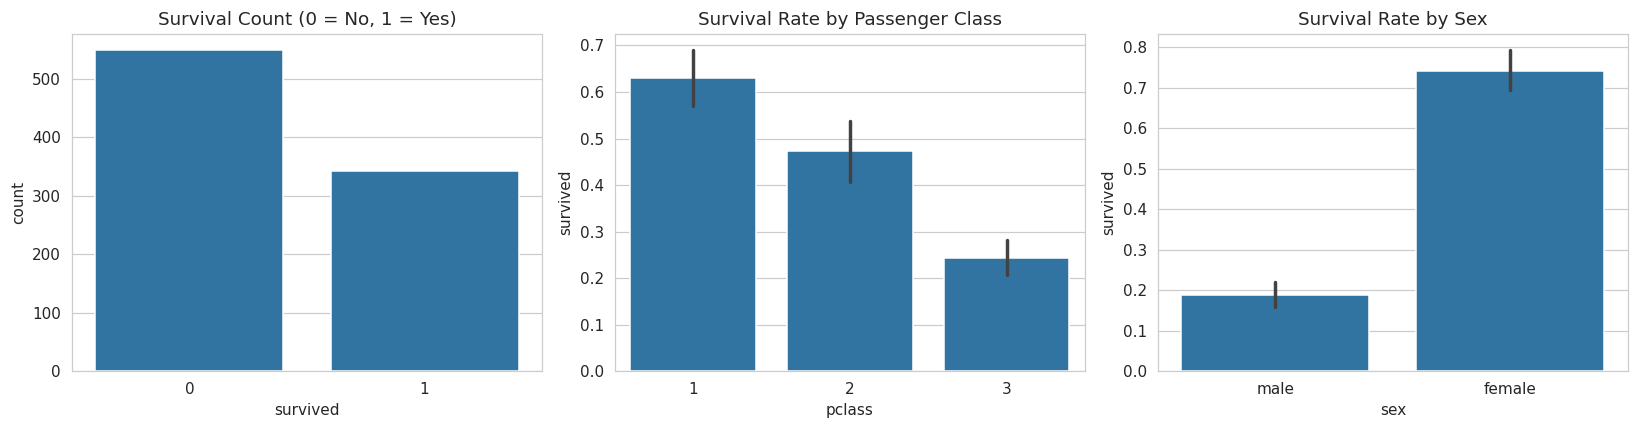

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=df, x="survived", ax=axes[0])
axes[0].set_title("Survival Count (0 = No, 1 = Yes)")

sns.barplot(data=df, x="pclass", y="survived", ax=axes[1])
axes[1].set_title("Survival Rate by Passenger Class")

sns.barplot(data=df, x="sex", y="survived", ax=axes[2])
axes[2].set_title("Survival Rate by Sex")

plt.tight_layout()
plt.savefig("images/survival_overview.png", bbox_inches="tight")
plt.show()

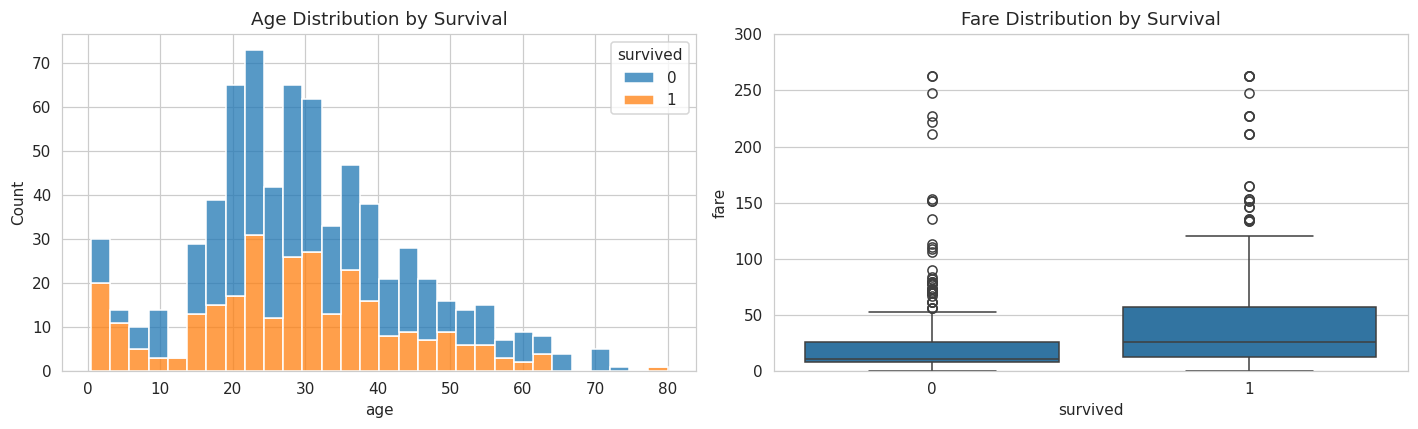

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(data=df, x="age", hue="survived", multiple="stack", bins=30, ax=axes[0])
axes[0].set_title("Age Distribution by Survival")

sns.boxplot(data=df, x="survived", y="fare", ax=axes[1])
axes[1].set_ylim(0, 300)
axes[1].set_title("Fare Distribution by Survival")

plt.tight_layout()
plt.savefig("images/age_fare_survival.png", bbox_inches="tight")
plt.show()

**Key observations:**
- Women had a far higher survival rate than men.
- 1st class passengers survived at a much higher rate than 3rd class.
- Passengers who paid higher fares (correlated with class) were more likely to survive.
- Young children show a noticeably higher survival rate than other age groups.


## 3. Feature Engineering

In [7]:
data = df.copy()

# Fill missing age with median age per passenger class (more accurate than a global median)
data["age"] = data.groupby("pclass")["age"].transform(lambda x: x.fillna(x.median()))

# Fill the 2 missing embarked values with the most common port
data["embarked"] = data["embarked"].fillna(data["embarked"].mode()[0])

# Family size feature
data["family_size"] = data["sibsp"] + data["parch"] + 1
data["is_alone"] = (data["family_size"] == 1).astype(int)

# Encode categoricals
data["sex"] = data["sex"].map({"male": 0, "female": 1})
data = pd.get_dummies(data, columns=["embarked"], drop_first=True)

features = ["pclass", "sex", "age", "fare", "family_size", "is_alone",
            "embarked_Q", "embarked_S"]
X = data[features]
y = data["survived"]

X.head()

,pclass,sex,age,fare,family_size,is_alone,embarked_Q,embarked_S
0,3,0,22.0,7.2500,2,0,False,True
1,1,1,38.0,71.2833,2,0,False,False
2,3,1,26.0,7.9250,1,1,False,True
3,1,1,35.0,53.1000,2,0,False,True
4,3,0,35.0,8.0500,1,1,False,True


## 4. Train / Test Split and Scaling

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 712, Test size: 179


## 5. Model Training and Comparison

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
}

results = {}

for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        cv_scores = cross_val_score(model, X_train, y_train, cv=5)

    acc = accuracy_score(y_test, preds)
    results[name] = {"test_accuracy": acc, "cv_mean": cv_scores.mean(), "cv_std": cv_scores.std()}
    print(f"{name}")
    print(f"  Test accuracy: {acc:.3f}")
    print(f"  Cross-val accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})\n")

Logistic Regression
  Test accuracy: 0.804
  Cross-val accuracy: 0.802 (+/- 0.032)



Random Forest
  Test accuracy: 0.799
  Cross-val accuracy: 0.787 (+/- 0.050)



## 6. Best Model: Detailed Evaluation

                 precision    recall  f1-score   support

Did not survive       0.82      0.85      0.84       110
       Survived       0.75      0.71      0.73        69

       accuracy                           0.80       179
      macro avg       0.79      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



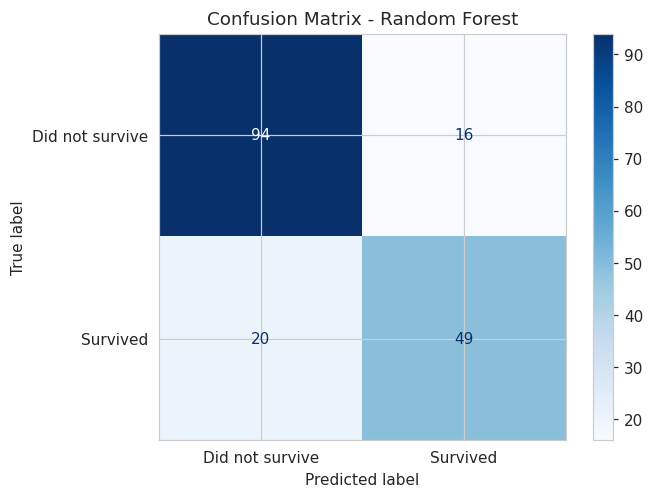

In [10]:
best_model = RandomForestClassifier(n_estimators=200, random_state=42)
best_model.fit(X_train, y_train)
preds = best_model.predict(X_test)

print(classification_report(y_test, preds, target_names=["Did not survive", "Survived"]))

cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Did not survive", "Survived"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.savefig("images/confusion_matrix.png", bbox_inches="tight")
plt.show()

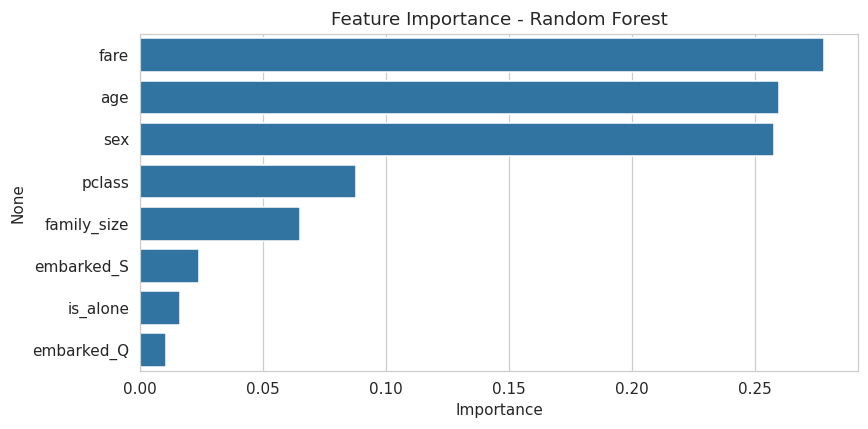

fare           0.278110
age            0.259975
sex            0.258030
pclass         0.088020
family_size    0.065276
embarked_S     0.023987
is_alone       0.016115
embarked_Q     0.010487
dtype: float64

In [11]:
importances = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("images/feature_importance.png", bbox_inches="tight")
plt.show()

importances

## 7. Conclusion

- **Logistic Regression** (80.4% test accuracy, 80.2% cross-validated) performed marginally better than **Random Forest** (79.9% test, 78.7% cross-validated) on this dataset — a reminder that simpler models can match or beat more complex ones on small, mostly-linear datasets like this.
- **Sex, fare, and passenger class** were the strongest predictors of survival, consistent with the historical "women and children first" evacuation policy and the fact that wealthier passengers had cabins closer to lifeboats.
- Possible next steps: hyperparameter tuning (GridSearchCV), trying gradient boosting models (XGBoost/LightGBM), and engineering title-based features from passenger names.
